# Lab 05: Power BI Basics, Architecture, and Data Cleaning
**Name:** Muneeb  
**Roll Number:** 24i2565  
**Section:** DS-B  


## Lab Questions & Core Concepts

### 1. Roles of Data Model, Power Query, and DAX in Power BI
* **Data Model:** When we import tables into Power BI, it builds a data model. It works like a database inside our file where we link tables together using relationships (for example, linking a Sales table to a Product table using Product ID).
* **Power Query (M Language):** This is the data cleaning tool inside Power BI. We use it before building charts to clean messy data, such as removing duplicate rows, fixing spelling mistakes, splitting columns, and changing data types.
* **DAX (Data Analysis Expressions):** This is the formula language in Power BI. We use it to write calculations like Total Sales, Profit, and KPI targets. Calculated columns work row by row, while measures calculate results on the fly based on filters.
* **Visuals:** These are the charts on our report page (bar charts, line charts, pie charts, slicers). Since all visuals connect to the same data model, selecting something in one visual automatically filters the others.

---

### 2. Power BI Desktop vs. Power BI Service
* **Power BI Desktop:**
  * Free software for Windows computers.
  * Used for all the main work: importing data, cleaning data in Power Query, building data models, writing DAX formulas, and designing report pages.
  * Works offline and saves files as `.pbix`.
* **Power BI Service:**
  * Cloud version accessible in any web browser (app.powerbi.com).
  * Used to share finished reports with teams, view dashboards, set email alerts on KPIs, and schedule automatic data refreshes.
  * Works on Mac and Linux too, but it does not support full data modeling or Power Query data cleaning.

---

### 3. What is a KPI (Key Performance Indicator)?
A KPI is a measurable number that shows how well a business or team is meeting its goal. Instead of showing just a plain number, a KPI compares the actual result with a target so we can see right away if performance is good or bad.

**A good KPI has these characteristics:**
* **Measurable:** Expressed as a clear number or percentage.
* **Time-bound:** Tracked over a set period (like monthly or yearly).
* **Goal-oriented:** Compared against a target value.
* **Actionable:** Helps managers make quick decisions if performance drops.

**The KPI visual in Power BI has three main parts:**
1. **Indicator:** The current actual value (e.g., Total Sales).
2. **Trend axis:** A line showing progress over time (e.g., months).
3. **Target / Goal:** The target number, usually colored green if we hit the target and red if we are below it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set clean styling for charts
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (10, 5)

### Loading Financial Dataset
We load the sample `Financial Sample.xlsx` dataset and clean column names by stripping any extra spaces.

In [2]:
# Load financial dataset
fin = pd.read_excel('Financial Sample.xlsx')
fin.columns = fin.columns.str.strip()

print(f"Dataset shape: {fin.shape}")
print("Columns:", fin.columns.tolist())
fin.head()

Dataset shape: (700, 16)
Columns: ['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.5,3,20,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014
1,Government,Germany,Carretera,NaN,1321.0,3,20,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014
2,Midmarket,France,Carretera,NaN,2178.0,3,15,32670.0,0.0,32670.0,21780.0,10890.0,2014-06-01,6,June,2014
3,Midmarket,Germany,Carretera,NaN,888.0,3,15,13320.0,0.0,13320.0,8880.0,4440.0,2014-06-01,6,June,2014
4,Midmarket,Mexico,Carretera,NaN,2470.0,3,15,37050.0,0.0,37050.0,24700.0,12350.0,2014-06-01,6,June,2014


---
## Task 1: Bar Chart of Sales by Product with Slicers

**Goal:** Build a bar chart of Sales by Product. Add a List Slicer for Country and a Tile Slicer for Segment, and test how selecting different values filters the chart.

**How to do it in Power BI:**
1. Click the **Clustered Bar Chart** icon in the Visualizations pane.
2. Put `Product` in the Y-axis and `Sales` in the X-axis.
3. Add a **Slicer** visual, drag `Country` into it, and choose **Vertical List** in Slicer settings.
4. Add another **Slicer** visual, drag `Segment` into it, and choose **Tile** in Slicer settings.
5. Clicking on any country or segment tile will automatically filter the bar chart.

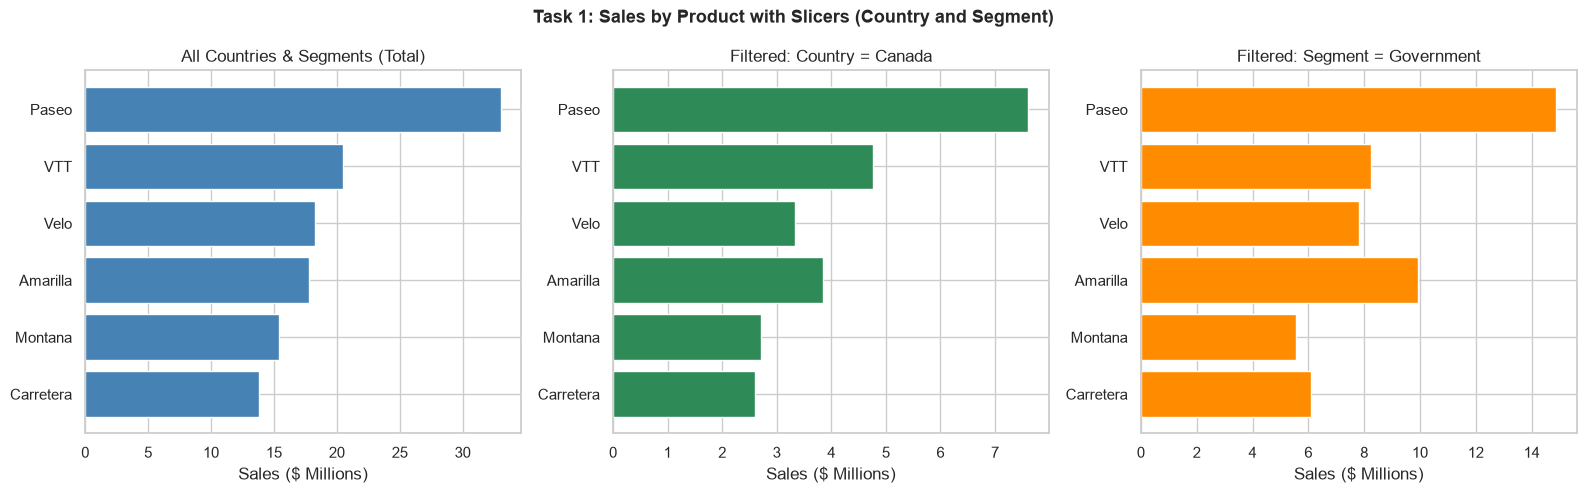

Total Sales by Product ($ Millions):
Product
Paseo        33.01
VTT          20.51
Velo         18.25
Amarilla     17.75
Montana      15.39
Carretera    13.82
Name: Sales, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. All Products (unfiltered)
p1 = fin.groupby('Product')['Sales'].sum().sort_values() / 1e6
axes[0].barh(p1.index, p1.values, color='steelblue')
axes[0].set_title('All Countries & Segments (Total)')
axes[0].set_xlabel('Sales ($ Millions)')

# 2. Filtered by Country = Canada (List Slicer)
p2 = fin[fin['Country'] == 'Canada'].groupby('Product')['Sales'].sum().reindex(p1.index) / 1e6
axes[1].barh(p2.index, p2.values, color='seagreen')
axes[1].set_title('Filtered: Country = Canada')
axes[1].set_xlabel('Sales ($ Millions)')

# 3. Filtered by Segment = Government (Tile Slicer)
p3 = fin[fin['Segment'] == 'Government'].groupby('Product')['Sales'].sum().reindex(p1.index) / 1e6
axes[2].barh(p3.index, p3.values, color='darkorange')
axes[2].set_title('Filtered: Segment = Government')
axes[2].set_xlabel('Sales ($ Millions)')

plt.suptitle('Task 1: Sales by Product with Slicers (Country and Segment)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Show sales values in a simple table
sales_summary = fin.groupby('Product')['Sales'].sum().sort_values(ascending=False) / 1e6
print("Total Sales by Product ($ Millions):")
print(sales_summary.round(2))

---
## Task 2: Line Chart of Sales with Date Hierarchy

**Goal:** Build a line chart of Sales using Date on the X-axis, and enable the automatic Date Hierarchy (Year -> Quarter -> Month -> Day).

**How to do it in Power BI:**
1. Click the **Line Chart** icon in the Visualizations pane.
2. Drag `Date` to the X-axis. Power BI automatically creates a Date Hierarchy with Year, Quarter, Month, and Day.
3. Drag `Sales` to the Y-axis.
4. Use the drill-down buttons at the top of the chart (down arrow to drill down into a year, or double down arrow to move to quarters or months).

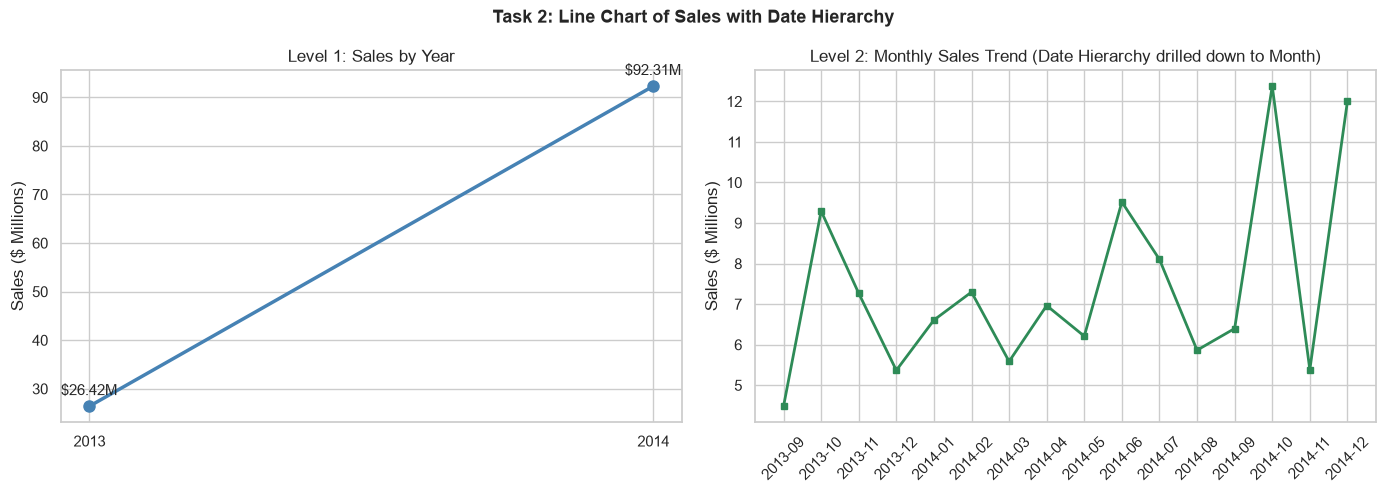

In [4]:
fin['Year'] = fin['Date'].dt.year
fin['YearMonth'] = fin['Date'].dt.to_period('M').astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Level 1: Yearly Sales
y_sales = fin.groupby('Year')['Sales'].sum() / 1e6
axes[0].plot(y_sales.index.astype(str), y_sales.values, marker='o', color='steelblue', linewidth=2.5, markersize=8)
axes[0].set_title('Level 1: Sales by Year')
axes[0].set_ylabel('Sales ($ Millions)')
for x, y in zip(y_sales.index.astype(str), y_sales.values):
    axes[0].annotate(f"${y:.2f}M", (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

# Level 2: Monthly Sales
m_sales = fin.groupby('YearMonth')['Sales'].sum() / 1e6
axes[1].plot(m_sales.index, m_sales.values, marker='s', color='seagreen', linewidth=2, markersize=5)
axes[1].set_title('Level 2: Monthly Sales Trend (Date Hierarchy drilled down to Month)')
axes[1].set_ylabel('Sales ($ Millions)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Task 2: Line Chart of Sales with Date Hierarchy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 3: Scatter Chart of Sales vs. Profit with Tooltips

**Goal:** Build a Scatter Chart plotting Sales (X-axis) against Profit (Y-axis), with Segment as the Legend. In the Tooltips field well, add Units Sold so hovering over any dot shows this extra detail.

**How to do it in Power BI:**
1. Click the **Scatter Chart** icon in the Visualizations pane.
2. Put `Sales` in the **X-axis** and `Profit` in the **Y-axis**.
3. Put `Segment` in the **Legend** well (this colors the dots by segment).
4. Drag `Units Sold` into the **Tooltips** well right below Legend.
5. When you hover over any dot in Power BI, the tooltip shows the Segment, Sales, Profit, and Units Sold.

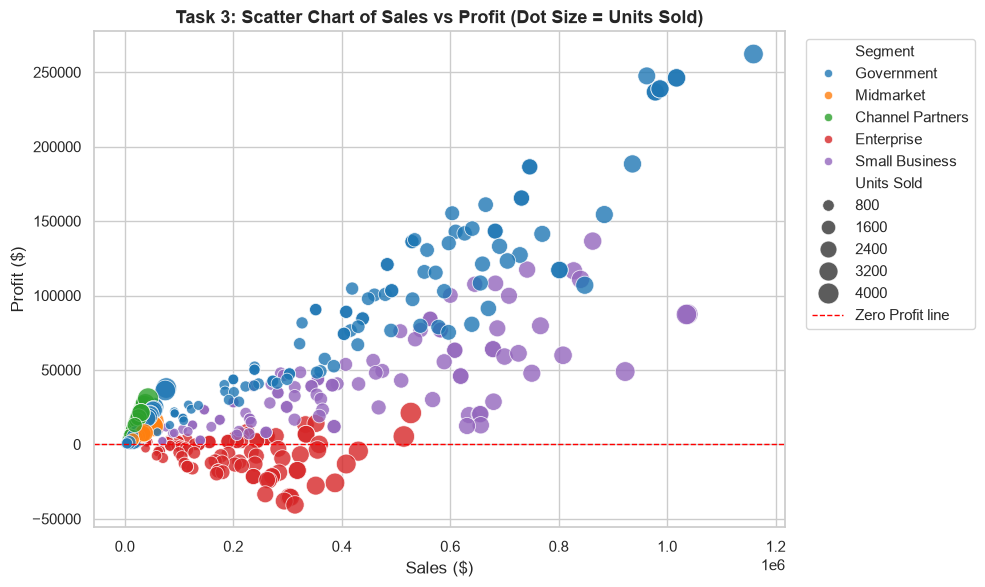

Summary by Segment:
                        Sales       Profit  Units Sold
Segment                                               
Channel Partners   1800593.64   1316803.14    161263.5
Enterprise        19611694.38   -614545.62    168552.0
Government        52504260.67  11388173.17    470673.5
Midmarket          2381883.08    660103.07    172178.0
Small Business    42427918.50   4143168.50    153139.0


In [5]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=fin,
    x='Sales',
    y='Profit',
    hue='Segment',
    size='Units Sold',
    sizes=(40, 250),
    alpha=0.8,
    palette='tab10'
)

plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Profit line')
plt.title('Task 3: Scatter Chart of Sales vs Profit (Dot Size = Units Sold)', fontsize=13, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Simple summary by Segment
print("Summary by Segment:")
print(fin.groupby('Segment')[['Sales', 'Profit', 'Units Sold']].sum().round(2))

---
## Task 4: KPI Visual

**Goal:** Create a KPI visual using the Financial dataset:
* **Value (Indicator):** Sum of Sales
* **Trend axis:** Date (Month)
* **Target:** A DAX measure (e.g. Sales Target = 500,000 or 5,000,000)

**How to do it in Power BI:**
1. Create a new measure for the target:
   ```dax
   Sales Target = 5000000
   ```
2. Click the **KPI** visual in the Visualizations pane.
3. Put `Sales` in **Value** (Indicator).
4. Put `Date` in **Trend axis**.
5. Put `Sales Target` in **Target goals**.
6. The KPI visual shows the current sales number, a line chart in the background, and green/red text showing if sales met the target.

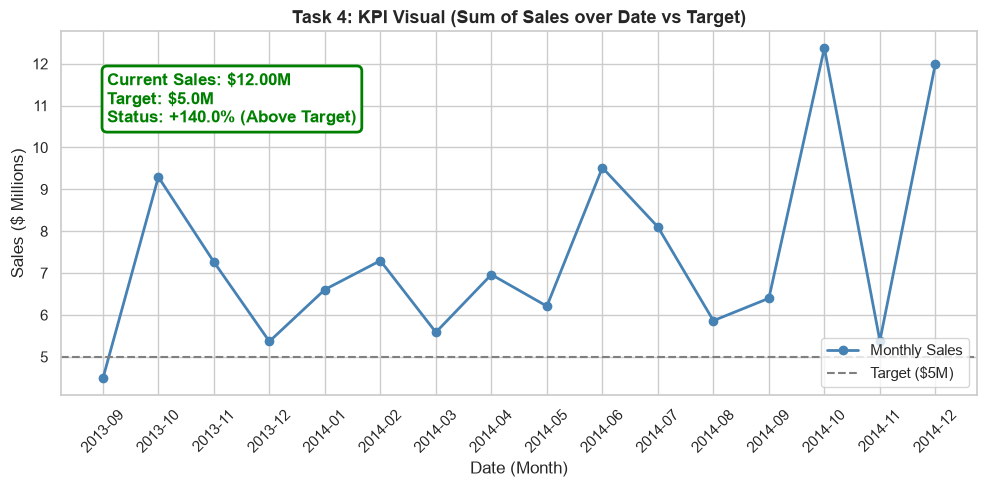

In [6]:
# Monthly Sales
monthly = fin.groupby('YearMonth')['Sales'].sum().reset_index()
monthly.columns = ['Month', 'Sales']

# Target: 5,000,000 monthly
TARGET = 5000000
monthly['Target'] = TARGET
monthly['Diff_Percent'] = ((monthly['Sales'] - TARGET) / TARGET) * 100

latest = monthly.iloc[-1]
status = "Above Target" if latest['Sales'] >= TARGET else "Below Target"
color = "green" if latest['Sales'] >= TARGET else "red"

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly['Month'], monthly['Sales'] / 1e6, color='steelblue', marker='o', linewidth=2, label='Monthly Sales')
ax.axhline(TARGET / 1e6, color='gray', linestyle='--', linewidth=1.5, label='Target ($5M)')
ax.set_title('Task 4: KPI Visual (Sum of Sales over Date vs Target)', fontsize=13, fontweight='bold')
ax.set_ylabel('Sales ($ Millions)')
ax.set_xlabel('Date (Month)')
ax.tick_params(axis='x', rotation=45)

# KPI card text
kpi_info = f"Current Sales: ${latest['Sales']/1e6:.2f}M\nTarget: ${TARGET/1e6:.1f}M\nStatus: {latest['Diff_Percent']:+.1f}% ({status})"
ax.text(0.05, 0.75, kpi_info, transform=ax.transAxes, fontsize=12, fontweight='bold', color=color,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor=color, linewidth=2))

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Task 5: Drill Through to a New Page

**Goal:** Using the line chart from Task 2, set up Drill Through to a new page containing the KPI visual from Task 4. Right-click on a month point on the line chart, choose Drill Through, and see the details for that month.

**How to do it in Power BI:**
1. Create a new report page and name it **Monthly Details**.
2. Add the KPI visual from Task 4 to this page.
3. In the page settings, find the **Drill-through** section and drag `Date` (or Month) into **Add drill-through fields here**.
4. Go back to the line chart on Page 1. Right-click any point on the line (e.g. October 2014) and select **Drill through -> Monthly Details**.
5. Power BI takes you to the new page, already filtered for that specific month.

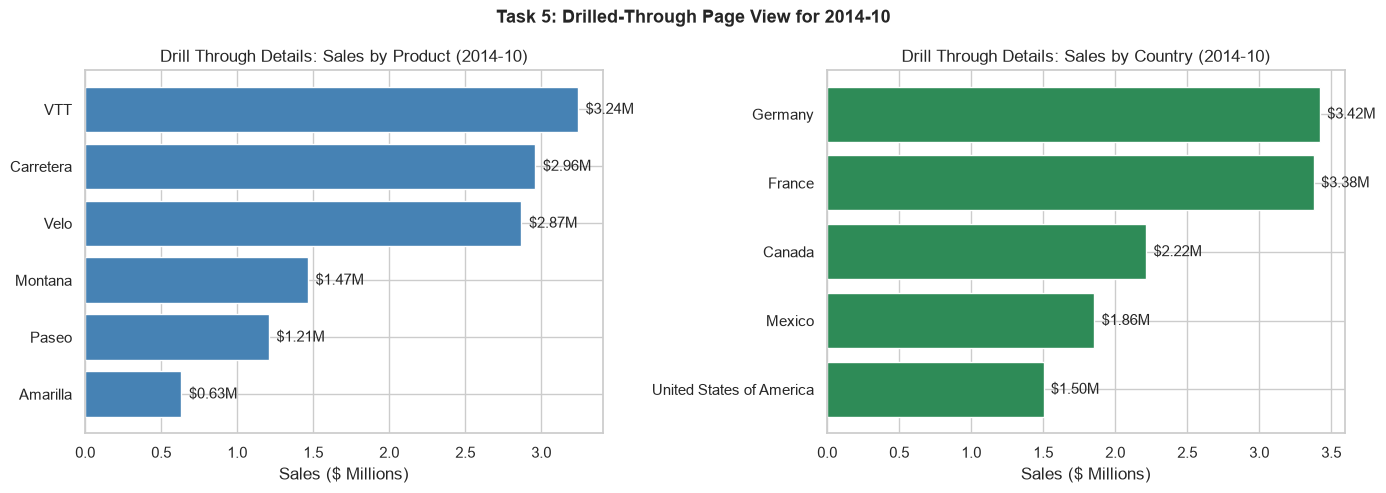

Total Sales in 2014-10: $12,375,819.92
Total Profit in 2014-10: $1,781,985.92


In [7]:
# Simulate drilling through to October 2014 (2014-10)
drill_month = '2014-10'
drill_data = fin[fin['YearMonth'] == drill_month]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Product Sales for drilled month
prod_drill = drill_data.groupby('Product')['Sales'].sum().sort_values() / 1e6
axes[0].barh(prod_drill.index, prod_drill.values, color='steelblue')
axes[0].set_title(f'Drill Through Details: Sales by Product ({drill_month})')
axes[0].set_xlabel('Sales ($ Millions)')
for i, v in enumerate(prod_drill.values):
    axes[0].text(v + 0.05, i, f"${v:.2f}M", va='center')

# 2. Country Sales for drilled month
country_drill = drill_data.groupby('Country')['Sales'].sum().sort_values() / 1e6
axes[1].barh(country_drill.index, country_drill.values, color='seagreen')
axes[1].set_title(f'Drill Through Details: Sales by Country ({drill_month})')
axes[1].set_xlabel('Sales ($ Millions)')
for i, v in enumerate(country_drill.values):
    axes[1].text(v + 0.05, i, f"${v:.2f}M", va='center')

plt.suptitle(f'Task 5: Drilled-Through Page View for {drill_month}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total Sales in {drill_month}: ${drill_data['Sales'].sum():,.2f}")
print(f"Total Profit in {drill_month}: ${drill_data['Profit'].sum():,.2f}")

---
## Task 6: Data Cleaning on textile_data.xlsx

**Goal:** Import `textile_data.xlsx` and clean it in Power Query:
1. Handle missing values.
2. Fix category inconsistencies (spelling, casing, spaces).
3. Fix numeric values (remove 'PKR', commas, and '%' signs, fix negative numbers).
4. Set correct data types.
5. Remove duplicates and blank rows.
6. Save the clean dataset as `textile_data_cleaned.csv` for submission.

In [8]:
# Load raw textile data
raw = pd.read_excel('textile_data.xlsx')
print(f"Raw shape: {raw.shape}")

# 1. Remove duplicate rows
clean_df = raw.drop_duplicates().copy()
print(f"Duplicates removed: {len(raw) - len(clean_df)}")

# 2. Fix Region categories (strip space, title case, fix spelling)
clean_df['Region'] = (
    clean_df['Region']
    .dropna()
    .astype(str)
    .str.strip()
    .str.title()
    .replace({'Lahor': 'Lahore', 'Faislabad': 'Faisalabad'})
)

# 3. Fix Fabric Type categories (strip space, title case, fix spelling)
clean_df['Fabric Type'] = (
    clean_df['Fabric Type']
    .dropna()
    .astype(str)
    .str.strip()
    .str.title()
    .replace({'Linnen': 'Linen', 'Poly-Ester': 'Polyester', 'Poly-ester': 'Polyester'})
)

# 4. Clean Product names
clean_df['Product'] = clean_df['Product'].dropna().astype(str).str.strip().str.title()

# 5. Fix numeric values in Revenue (remove PKR, commas)
def clean_revenue(val):
    if pd.isna(val):
        return np.nan
    s = str(val).replace('PKR', '').replace(',', '').strip()
    try:
        return float(s)
    except:
        return np.nan

clean_df['Revenue'] = clean_df['Revenue'].apply(clean_revenue)

# 6. Fix Quantity (make negative values positive)
clean_df['Quantity (Meters)'] = clean_df['Quantity (Meters)'].abs()

# 7. Fix Defect Rate (remove % and make negative values positive)
def clean_defect_rate(val):
    if pd.isna(val):
        return np.nan
    s = str(val).replace('%', '').strip()
    try:
        return abs(float(s))
    except:
        return np.nan

clean_df['Defect Rate (%)'] = clean_df['Defect Rate (%)'].apply(clean_defect_rate)

# 8. Convert Date
clean_df['Date'] = pd.to_datetime(clean_df['Date'], format='mixed', errors='coerce')

# 9. Fill missing values
# Fill missing categories with mode
clean_df['Region'] = clean_df['Region'].fillna(clean_df['Region'].mode()[0])
clean_df['Fabric Type'] = clean_df['Fabric Type'].fillna(clean_df['Fabric Type'].mode()[0])
clean_df['Product'] = clean_df['Product'].fillna(clean_df['Product'].mode()[0])

# Fill missing Quantity and Revenue using median price per fabric
unit_prices = (clean_df['Revenue'] / clean_df['Quantity (Meters)']).groupby(clean_df['Fabric Type']).median()
overall_unit_price = (clean_df['Revenue'] / clean_df['Quantity (Meters)']).median()

# Fill missing Revenue where Quantity exists
mask_rev = clean_df['Revenue'].isnull() & clean_df['Quantity (Meters)'].notnull()
clean_df.loc[mask_rev, 'Revenue'] = clean_df.loc[mask_rev].apply(
    lambda r: round(r['Quantity (Meters)'] * unit_prices.get(r['Fabric Type'], overall_unit_price), 2), axis=1
)

# Fill missing Quantity where Revenue exists
mask_qty = clean_df['Quantity (Meters)'].isnull() & clean_df['Revenue'].notnull()
clean_df.loc[mask_qty, 'Quantity (Meters)'] = clean_df.loc[mask_qty].apply(
    lambda r: round(r['Revenue'] / unit_prices.get(r['Fabric Type'], overall_unit_price), 0), axis=1
)

# Fill remaining missing numbers with median
clean_df['Quantity (Meters)'] = clean_df['Quantity (Meters)'].fillna(clean_df['Quantity (Meters)'].median())
clean_df['Revenue'] = clean_df['Revenue'].fillna(clean_df['Quantity (Meters)'] * overall_unit_price)
clean_df['Defect Rate (%)'] = clean_df['Defect Rate (%)'].fillna(clean_df['Defect Rate (%)'].median())

# Fill missing dates using forward fill
clean_df['Date'] = clean_df['Date'].ffill().bfill()

# Save cleaned CSV file
clean_df.to_csv('textile_data_cleaned.csv', index=False)
print("Cleaned dataset saved as 'textile_data_cleaned.csv'")
print("Cleaned shape:", clean_df.shape)
print("Remaining missing values:\n", clean_df.isnull().sum())
clean_df.head()

Raw shape: (68, 9)
Duplicates removed: 3
Cleaned dataset saved as 'textile_data_cleaned.csv'
Cleaned shape: (65, 9)
Remaining missing values:
 OrderID              0
Date                 0
Region               0
Fabric Type          0
Product              0
Buyer Type           0
Quantity (Meters)    0
Revenue              0
Defect Rate (%)      0
dtype: int64


,OrderID,Date,Region,Fabric Type,Product,Buyer Type,Quantity (Meters),Revenue,Defect Rate (%)
0,TX-2000,2023-11-28,Punjab,Cotton,Garment Lot,Local Retailer,3602.0,32994.32,6.79
1,TX-2001,2023-03-05,Multan,Silk,Garment Lot,Export - USA,4639.0,44348.84,5.95
2,TX-2002,2023-03-03,Multan,Polyester,Curtain Cloth,Export - Europe,1522.0,14413.34,8.75
3,TX-2003,2024-03-04,Sindh,Cotton,Shirt Fabric,Export - USA,4919.0,14215.91,3.24
4,TX-2004,2023-11-14,Multan,Denim,Curtain Cloth,Local Retailer,285.0,2114.24,10.46


---
## Task 7: Report Page on Cleaned Textile Data

**Goal:** Build a report page using the cleaned textile data:
1. A **Card visual** showing Total Revenue (or Quantity in Meters).
2. A **Slicer** for Region (or Fabric Type).
3. A **Pie chart** showing Revenue breakdown by Fabric Type (or Buyer Type).

**How to do it in Power BI:**
1. Click **Card visual** and drag `Revenue` into Fields.
2. Click **Slicer visual** and drag `Region` into Field.
3. Click **Pie Chart visual**, put `Fabric Type` in Legend, and `Revenue` in Values.

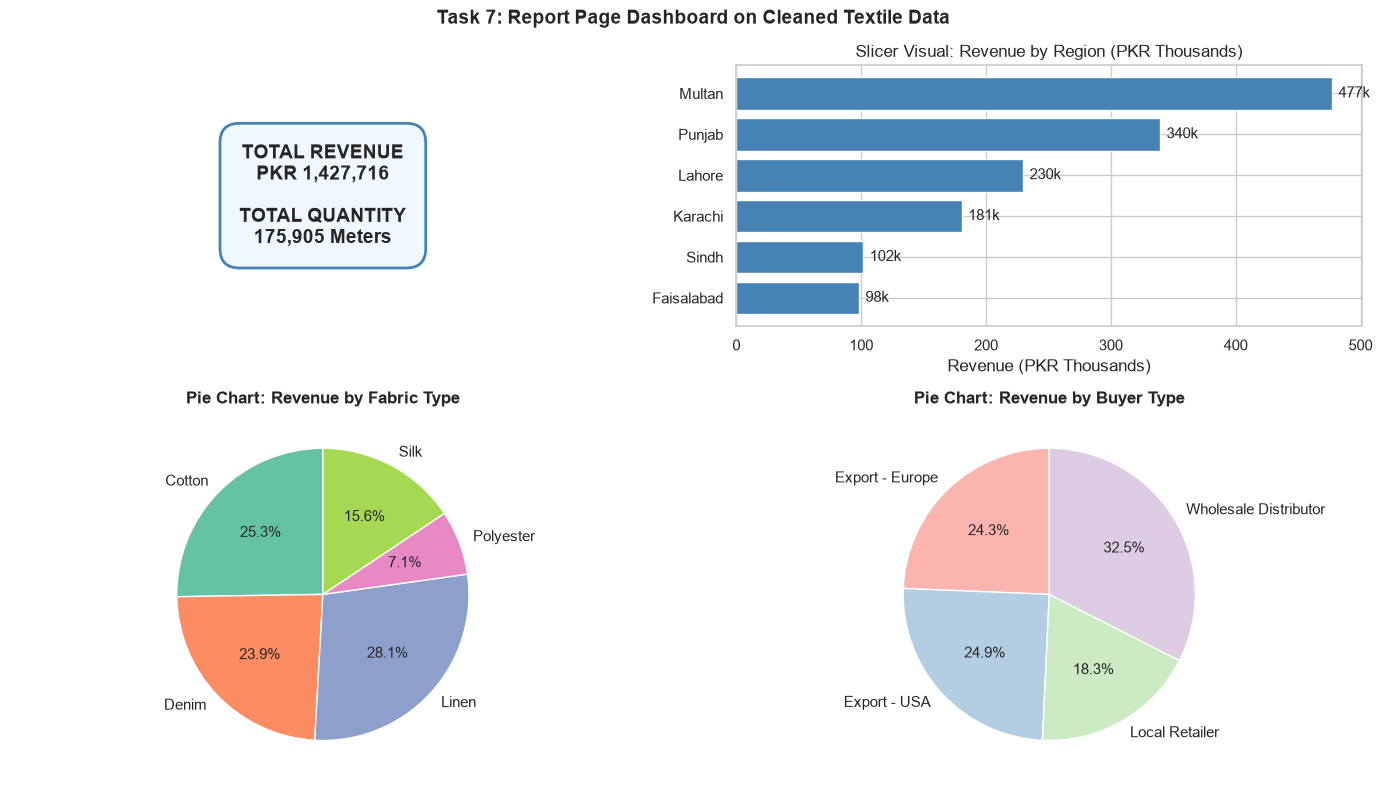

In [9]:
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.4])

# 1. Card Visual (Total Revenue & Total Quantity)
ax_card = fig.add_subplot(gs[0, 0])
ax_card.axis('off')
total_rev = clean_df['Revenue'].sum()
total_qty = clean_df['Quantity (Meters)'].sum()
card_text = f"TOTAL REVENUE\nPKR {total_rev:,.0f}\n\nTOTAL QUANTITY\n{total_qty:,.0f} Meters"
ax_card.text(0.5, 0.5, card_text, fontsize=14, fontweight='bold', ha='center', va='center',
             bbox=dict(boxstyle='round,pad=1', facecolor='#f0f8ff', edgecolor='steelblue', linewidth=2))

# 2. Slicer Visual: Revenue by Region
ax_bar = fig.add_subplot(gs[0, 1])
reg_sales = clean_df.groupby('Region')['Revenue'].sum().sort_values() / 1e3
ax_bar.barh(reg_sales.index, reg_sales.values, color='steelblue')
ax_bar.set_title('Slicer Visual: Revenue by Region (PKR Thousands)')
ax_bar.set_xlabel('Revenue (PKR Thousands)')
for i, v in enumerate(reg_sales.values):
    ax_bar.text(v + 5, i, f"{v:,.0f}k", va='center')

# 3. Pie Chart: Revenue by Fabric Type
ax_pie1 = fig.add_subplot(gs[1, 0])
fab_sales = clean_df.groupby('Fabric Type')['Revenue'].sum()
ax_pie1.pie(fab_sales.values, labels=fab_sales.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
ax_pie1.set_title('Pie Chart: Revenue by Fabric Type', fontweight='bold')

# 4. Pie Chart: Revenue by Buyer Type
ax_pie2 = fig.add_subplot(gs[1, 1])
buyer_sales = clean_df.groupby('Buyer Type')['Revenue'].sum()
ax_pie2.pie(buyer_sales.values, labels=buyer_sales.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Pastel1'))
ax_pie2.set_title('Pie Chart: Revenue by Buyer Type', fontweight='bold')

plt.suptitle('Task 7: Report Page Dashboard on Cleaned Textile Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary of Work Done
* Answered questions about Power BI Architecture, Desktop vs Service, and KPIs in simple terms.
* Completed Tasks 1 to 5 using the Financial dataset:
  * Bar chart with Country and Segment slicers.
  * Line chart with Date hierarchy.
  * Scatter plot with Segment legend and Units Sold.
  * KPI visual comparing sales with a target.
  * Drill-through navigation to a detailed month view.
* Completed Task 6 by cleaning `textile_data.xlsx` (fixing duplicates, spelling mistakes, negative values, and missing data) and exported `textile_data_cleaned.csv`.
* Completed Task 7 by building the report page with Card, Slicer, and Pie charts.